<a href="https://colab.research.google.com/github/sandip-1996/PRML_exercise_code_example/blob/Probability-distribution-ch.-2/Kernel_Density_estimator_KDE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, fetch_california_housing

data = fetch_california_housing()
X = data.data[:,0]

# normalize for stability
X = (X - X.mean())/X.std()

# sort for visualization purpose
X = np.sort(X)
N = len(X)
print(X)

[-1.77429947 -1.77429947 -1.77429947 ...  5.85828581  5.85828581
  5.85828581]


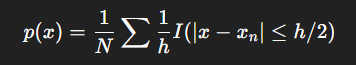

first we use box kernel method

In [35]:
def box_kernel(x_points, data, h):
  densities = []
  for x in x_points:
    count = 0

    for xn in data:
      if abs(x - xn) <= h/2:
        count += 1

    density = count / (len(data)*h)
    densities.append(density)

  return np.array(densities)

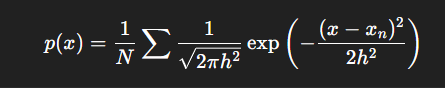

now we use gaussian kernel method


In [36]:
def gaussian_kernel(x_points, data, h):
  densities = []
  for x in x_points:
    total = 0

    for xn in data:
      kernel_val = np.exp(-0.5*((x - xn)/h)**2)/np.sqrt(2*np.pi)
      total += kernel_val

    density = total/(len(data)*h)
    densities.append(density)

  return np.array(densities)

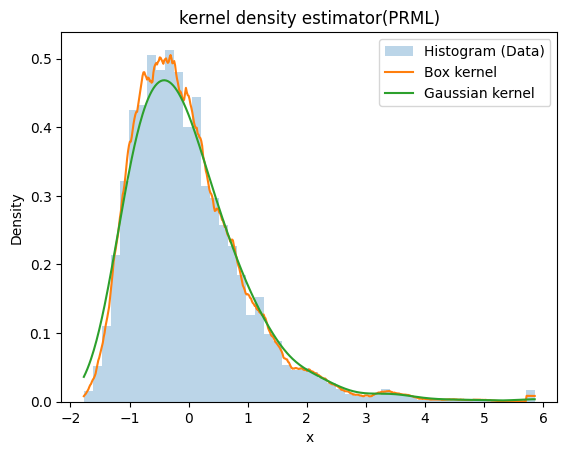

In [37]:

x_grid = np.linspace(X.min(),X.max(), 500)

#let bins bandwidth 0.3
h = 0.3

box_density = box_kernel(x_grid, X, h)
gaussian_density = gaussian_kernel(x_grid, X, h)

#plot
plt.figure()

plt.hist(X, bins=50, density=True, alpha=0.3, label = "Histogram (Data)")
plt.plot(x_grid, box_density, label="Box kernel")
plt.plot(x_grid, gaussian_density, label="Gaussian kernel")

plt.legend()
plt.title("kernel density estimator(PRML)")
plt.xlabel("x")
plt.ylabel("Density")

plt.show()
